# KV Cache Precision Experiments

This notebook walks through the full Topic 2 investigation:
1. Load a model and inspect the raw KV cache
2. Measure memory footprint at different precisions
3. Quantify the error introduced by compression
4. Sweep context lengths to see how FP8/INT8 savings scale
5. Simulate concurrency to find the OOM ceiling
6. Measure latency (TPOT) across configurations

**Note:** We use GPT-2 here so everything runs on a laptop/Colab CPU.  
On the server, swap `model_id` to `meta-llama/Meta-Llama-3-8B-Instruct` and `device` to `cuda`.

In [1]:
import sys
sys.path.insert(0, '../src')

from llm_serving.kv_cache import (
    load_model,
    extract_kv_cache,
    profile_kv_cache,
    print_cache_profile,
    convert_kv_cache_precision,
    compare_precisions,
    measure_quantization_error,
    measure_perplexity,             # <--- Add this here
    measure_generation_latency,
    simulate_batch_concurrency,
    sweep_context_lengths,
)
from llm_serving.plotting import (
    plot_cache_size_comparison,
    plot_concurrency_throughput,
    plot_quantization_error,
    plot_precision_memory_bar,
    plot_latency_comparison,
)
import torch
print('All imports successful!')

C:\Users\pantm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful!


## 1. Load the Model

Using GPT-2 (124M params) for local development.  
Change `model_id` and `device` when you move to the server.

In [2]:
# ------ CONFIGURATION (change these on the server) ------
MODEL_ID = "gpt2"                    # server: "meta-llama/Meta-Llama-3-8B-Instruct"
DEVICE = "cpu"                       # server: "cuda"
# --------------------------------------------------------

model, tokenizer = load_model(MODEL_ID, DEVICE)

Loaded gpt2 on cpu
  Parameters: 124.4M
  Weight dtype: torch.float32


## 2. Inspect the Raw KV Cache

Run a single forward pass and look at what the KV cache actually contains —  
its shape, dtype, and memory footprint.

In [3]:
prompt = "The future of artificial intelligence is"

kv_cache, outputs = extract_kv_cache(model, tokenizer, prompt, DEVICE)

profile = profile_kv_cache(kv_cache)
print("\n--- KV Cache Profile ---")
print_cache_profile(profile)


--- KV Cache Profile ---
  Layers: 12
  Heads per layer: 12
  Head dimension: 64
  Sequence length: 6
  Dtype: torch.float32
  Total size: 0.4219 MB (442,368 bytes)


## 3. Compare Precision Formats

Simulate compressing the cache to FP16 and INT8 (standing in for FP8).  
Measure exactly how many bytes we save and how many more tokens we could  
theoretically fit in a 10 GB memory budget.

In [4]:
# Compare against FP16
comp_fp16 = compare_precisions(kv_cache, torch.float16)
print(f"FP32 -> FP16:")
print(f"  Original: {comp_fp16.original_size_mb:.4f} MB")
print(f"  Compressed: {comp_fp16.compressed_size_mb:.4f} MB")
print(f"  Saved: {comp_fp16.memory_saved_pct:.1f}%")
print(f"  Max tokens in 10GB (original): {comp_fp16.max_seq_at_original:,}")
print(f"  Max tokens in 10GB (compressed): {comp_fp16.max_seq_at_compressed:,}")

print()

# Compare against INT8 (simulating FP8)
comp_int8 = compare_precisions(kv_cache, torch.int8)
print(f"FP32 -> INT8 (simulating FP8):")
print(f"  Original: {comp_int8.original_size_mb:.4f} MB")
print(f"  Compressed: {comp_int8.compressed_size_mb:.4f} MB")
print(f"  Saved: {comp_int8.memory_saved_pct:.1f}%")
print(f"  Max tokens in 10GB (original): {comp_int8.max_seq_at_original:,}")
print(f"  Max tokens in 10GB (compressed): {comp_int8.max_seq_at_compressed:,}")

FP32 -> FP16:
  Original: 0.4219 MB
  Compressed: 0.2109 MB
  Saved: 50.0%
  Max tokens in 10GB (original): 145,635
  Max tokens in 10GB (compressed): 291,271

FP32 -> INT8 (simulating FP8):
  Original: 0.4219 MB
  Compressed: 0.1056 MB
  Saved: 75.0%
  Max tokens in 10GB (original): 145,635
  Max tokens in 10GB (compressed): 582,036


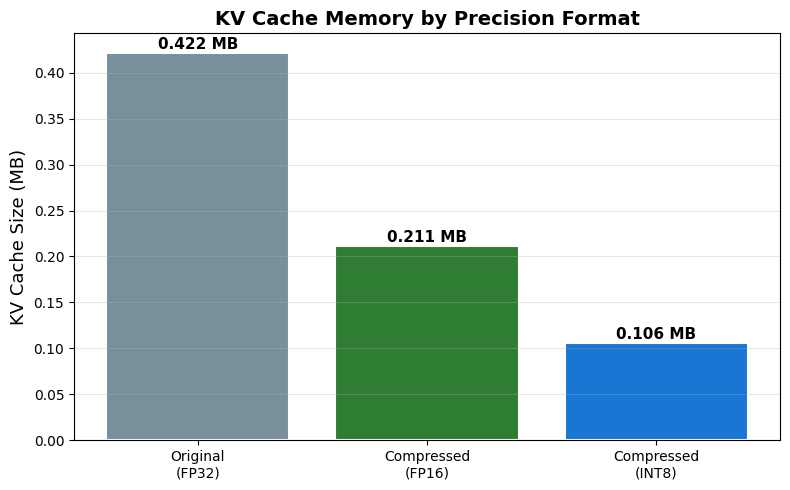

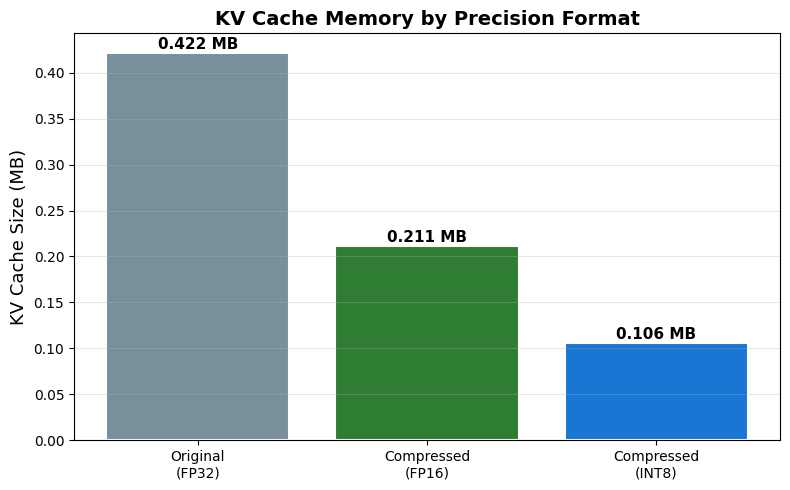

In [5]:
# Visualise the comparison
plot_precision_memory_bar({"FP16": comp_fp16, "INT8": comp_int8})

## 4. Quantization Error Analysis

Measure how much numerical error INT8 quantization introduces per layer.  
This is our proxy for output quality — if certain layers have high error,  
that's where quality degradation will show up first.

Per-layer quantization error (INT8):
  Layer  0: Key MSE=0.000282, Value MSE=0.000032, Key MaxErr=0.0293
  Layer  1: Key MSE=0.000111, Value MSE=0.000074, Key MaxErr=0.0183
  Layer  2: Key MSE=0.000153, Value MSE=0.000076, Key MaxErr=0.0215
  Layer  3: Key MSE=0.001013, Value MSE=0.000062, Key MaxErr=0.0554
  Layer  4: Key MSE=0.001275, Value MSE=0.000044, Key MaxErr=0.0618
  Layer  5: Key MSE=0.000465, Value MSE=0.000080, Key MaxErr=0.0375
  Layer  6: Key MSE=0.000831, Value MSE=0.000060, Key MaxErr=0.0499
  Layer  7: Key MSE=0.000768, Value MSE=0.000071, Key MaxErr=0.0478
  Layer  8: Key MSE=0.000336, Value MSE=0.000098, Key MaxErr=0.0314
  Layer  9: Key MSE=0.000387, Value MSE=0.000095, Key MaxErr=0.0340
  Layer 10: Key MSE=0.000355, Value MSE=0.000108, Key MaxErr=0.0328
  Layer 11: Key MSE=0.000102, Value MSE=0.000971, Key MaxErr=0.0174


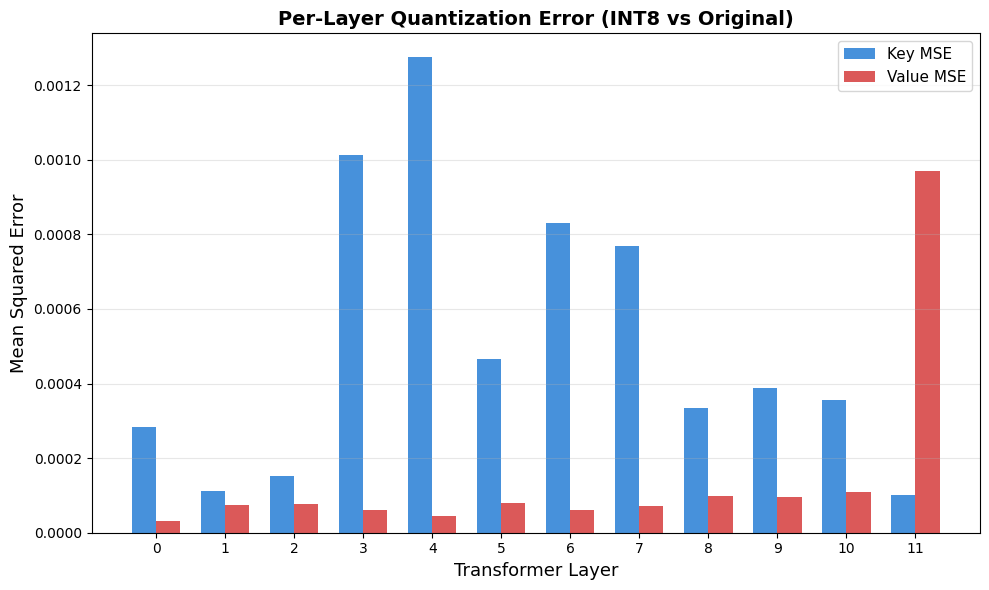

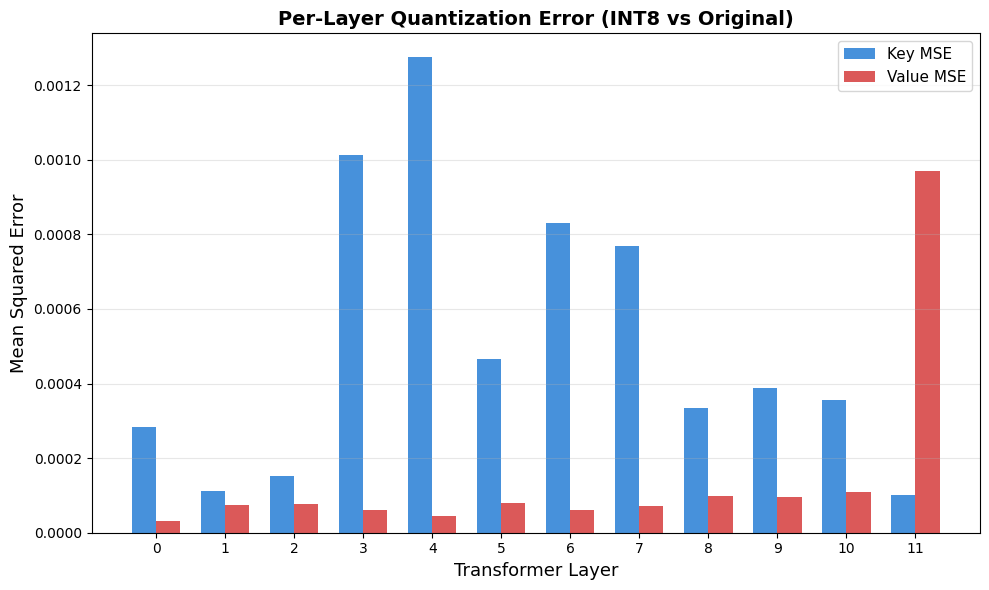

In [5]:
errors = measure_quantization_error(kv_cache, torch.int8)

print("Per-layer quantization error (INT8):")
for e in errors:
    print(f"  Layer {e['layer']:2d}: Key MSE={e['key_mse']:.6f}, "
          f"Value MSE={e['value_mse']:.6f}, "
          f"Key MaxErr={e['key_max_abs_error']:.4f}")

plot_quantization_error(errors, "INT8")

## 4.5 Perplexity Measurement (Quality Degradation)

While MSE tells us if the tensor math changed, **Perplexity** tells us if the model's actual language understanding degraded. Lower is better.

When testing Topic 2, you will run a large benchmark dataset (like WikiText) through this function. If the FP8 perplexity is drastically higher than the FP16 baseline, the compression failed.

In [6]:
# A sample text to test the model's understanding
sample_text = """
Large language models generate text autoregressively. This means they predict 
the next word based on all the previous words. To do this efficiently, they 
store the previous states in a Key-Value cache.
"""

baseline_ppl = measure_perplexity(model, tokenizer, sample_text, DEVICE)

print(f"--- Quality Metric ---")
print(f"Baseline Perplexity: {baseline_ppl:.4f}")
print(f"Note: On the server, you will compare this baseline against the FP8 model.")

`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


--- Quality Metric ---
Baseline Perplexity: 112.1526
Note: On the server, you will compare this baseline against the FP8 model.


## 5. Context Length Sweep

Measure how KV cache size grows with context length, and how much  
INT8/FP8 compression saves at each length.  

This answers: *"How does the benefit change with context length?"*

Sweeping context lengths...
  ctx=   21: FP32=1.477 MB, INT8=0.369 MB, saved=75.0%
  ctx=   51: FP32=3.586 MB, INT8=0.897 MB, saved=75.0%
  ctx=  111: FP32=7.805 MB, INT8=1.951 MB, saved=75.0%
  ctx=  231: FP32=16.242 MB, INT8=4.061 MB, saved=75.0%
  ctx=  461: FP32=32.414 MB, INT8=8.104 MB, saved=75.0%


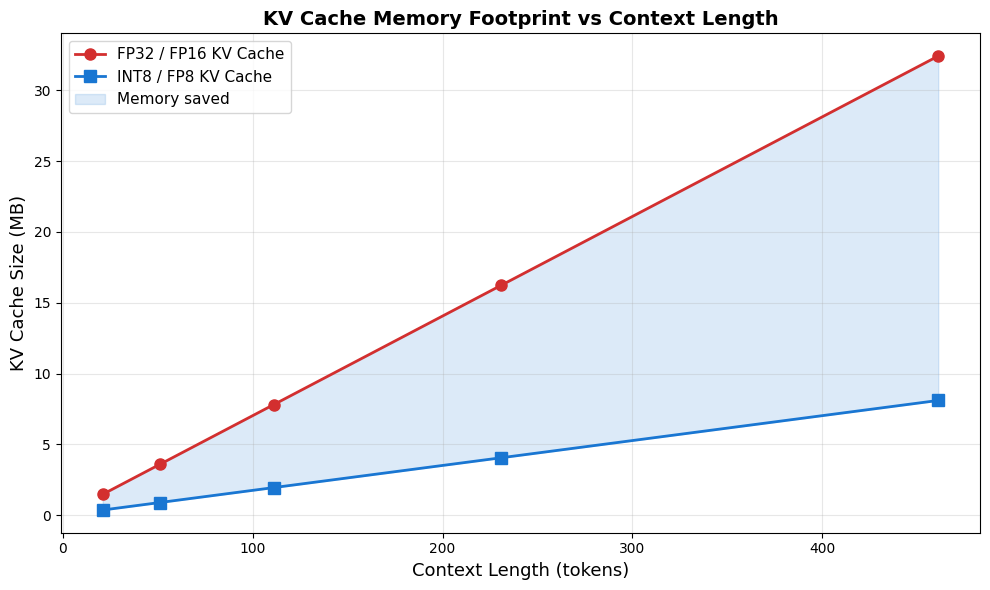

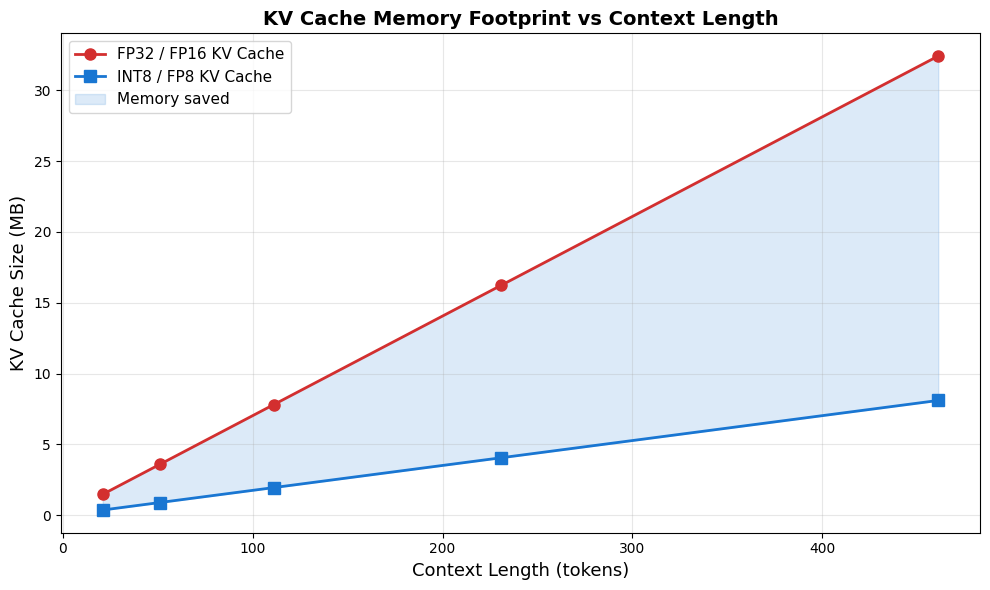

In [7]:
# GPT-2 max context is 1024. On the server with Llama-3, use [512, 1024, 2048, 4096, 8192]
context_lengths = [32, 64, 128, 256, 512]

print("Sweeping context lengths...")
ctx_results = sweep_context_lengths(model, tokenizer, context_lengths, DEVICE)

plot_cache_size_comparison(ctx_results)

## 6. Batch Concurrency Simulation

Simulate increasing the number of concurrent users by growing the batch size.  
This finds the OOM point — your concurrency ceiling.

On a laptop/CPU this won't OOM (it'll just get slow), but on the GPU server  
you will see it crash at a specific batch size. That crash point is your data.

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Running batch concurrency sweep...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


  Batch 1: 12.3 tok/s, 1.63s total


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


  Batch 2: 27.6 tok/s, 1.45s total


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


  Batch 4: 49.5 tok/s, 1.62s total


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


  Batch 8: 111.9 tok/s, 1.43s total
  Batch 16: 191.6 tok/s, 1.67s total


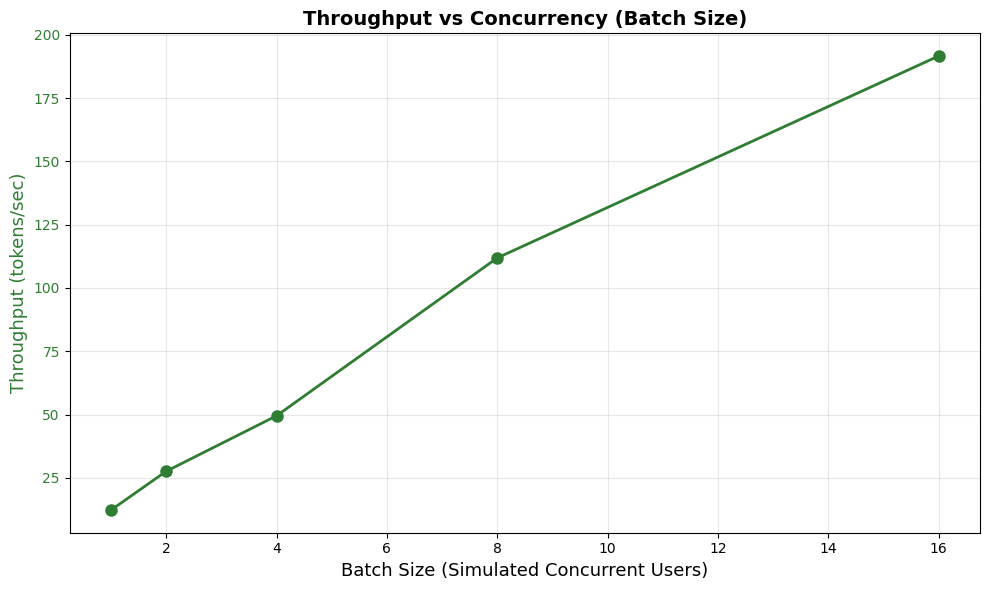

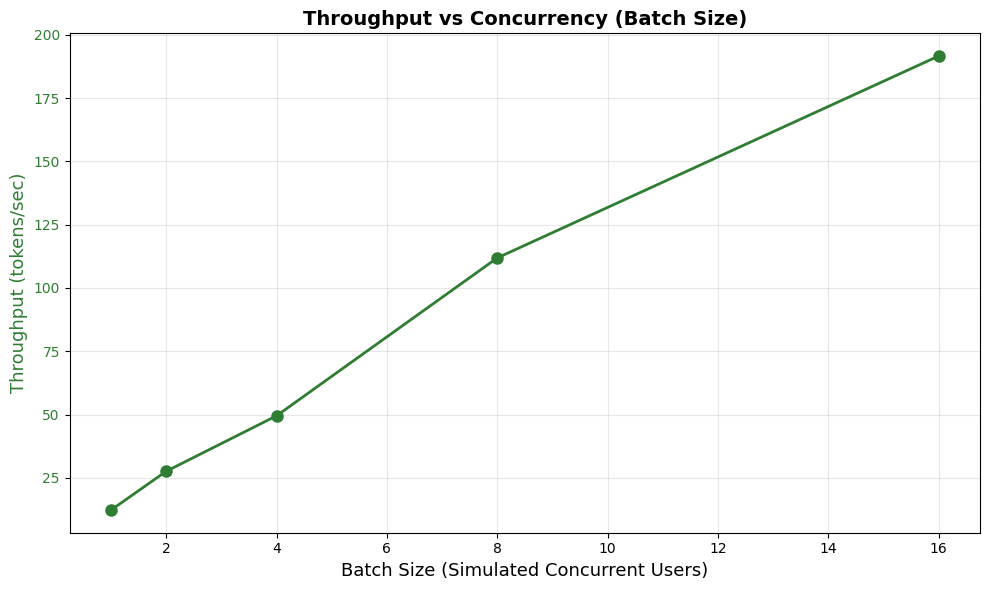

In [8]:
batch_sizes = [1, 2, 4, 8, 16]
# On the server with GPU: batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128]

prompt = "Explain the concept of attention in transformers."

print("Running batch concurrency sweep...")
batch_results = simulate_batch_concurrency(
    model, tokenizer, prompt,
    batch_sizes=batch_sizes,
    max_new_tokens=20,
    device=DEVICE,
)

plot_concurrency_throughput(batch_results)

## 7. Latency Measurement (TPOT / TTFT)

Measure how fast the model generates tokens. This is the baseline  
that speculative decoding (Topic 3) will try to beat.

In [9]:
prompt = "The key challenge in deploying large language models is"

result = measure_generation_latency(
    model, tokenizer, prompt,
    max_new_tokens=50,
    device=DEVICE,
)

print(f"--- Generation Latency ---")
print(f"  Tokens generated: {result.num_tokens_generated}")
print(f"  Total time: {result.total_time_sec:.3f}s")
print(f"  Time to first token (TTFT): {result.time_to_first_token_sec:.3f}s")
print(f"  Time per output token (TPOT): {result.time_per_output_token_ms:.1f}ms")
print(f"  Tokens/sec: {result.tokens_per_sec:.1f}")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


--- Generation Latency ---
  Tokens generated: 50
  Total time: 3.828s
  Time to first token (TTFT): 0.076s
  Time per output token (TPOT): 76.6ms
  Tokens/sec: 13.1


## Next Steps

When you get server access:
1. Change `MODEL_ID` to `meta-llama/Meta-Llama-3-8B-Instruct`
2. Change `DEVICE` to `cuda`
3. Expand `context_lengths` to `[512, 1024, 2048, 4096, 8192]`
4. Expand `batch_sizes` to `[1, 2, 4, 8, 16, 32, 64, 128]`
5. Run MMLU / HumanEval benchmarks to check quality degradation
6. Use vLLM with `--kv-cache-dtype fp8` for native FP8 support